# Locally Weighted Regression

Study Hours vs Marks example with executed output.

Study Hour   Mark   Weight
---------------------------
    1        35   0.000
    2        45   0.000
    3        52   0.000
    4        60   0.000
    5        68   0.002
    6        75   0.044
    7        82   0.325
    8        88   0.882
    9        93   0.882

New student studies: 8.5 hours
Predicted Mark: 90.44


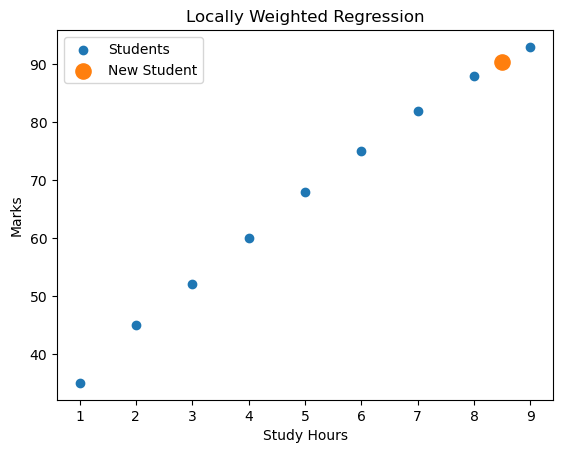

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([35, 45, 52, 60, 68, 75, 82, 88, 93])

# New student
query = 8.5

# Bandwidth controls how local the model is
tau = 1.0

# Calculate weights
weights = np.exp(-((X - query) ** 2) / (2 * tau ** 2))

print("Study Hour   Mark   Weight")
print("---------------------------")

for hour, mark, weight in zip(X, y, weights):
    print(f"{hour:^10} {mark:^6} {weight:.3f}")

# Add column of 1s for intercept
X_design = np.column_stack((np.ones(len(X)), X))

# Weighted Linear Regression
W = np.diag(weights)

theta = np.linalg.pinv(
    X_design.T @ W @ X_design
) @ X_design.T @ W @ y

# Prediction
prediction = np.array([1, query]) @ theta

print("\nNew student studies:", query, "hours")
print("Predicted Mark:", round(prediction, 2))

# Plot
plt.scatter(X, y, label="Students")
plt.scatter(query, prediction, s=120, label="New Student")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Locally Weighted Regression")
plt.legend()
plt.show()
